In [49]:
import pandas as pd
import numpy as np
import datetime
from epiweeks import Week
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from datetime import timedelta
from matplotlib.lines import Line2D
import math

import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter


import warnings
warnings.filterwarnings('ignore')

In [2]:
flu_hindcast = pd.read_parquet('benchmark forecasts/hindcasts/FluSight-hosp-hindcast-quantiles.parquet')
flu_hindcast['Model'] = 'hindcast'

flu_naive = pd.read_parquet('benchmark forecasts/naive/naive_flu_hosp_h12.parquet')
flu_naive['Model'] = 'naive'

flu_baseline = pd.read_parquet('benchmark forecasts/random walk baseline/flu_hosp_log_baseline_h12.pq')
flu_baseline['Model'] = 'baseline'

flu_ets = pd.read_parquet('benchmark forecasts/trend baseline/flu_weeklyhosp_ets_models.parquet')
flu_ets['Model'] = 'ETS'

In [3]:
def pull_flu_surveillance_data():
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})


def pull_flusight_predictions(model,date):
    """pull_flusight_predictions. Load predictions of the model saved by the Flusight forecast hub

    Parameters
    ----------
    model : str
        Model name on the
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/model-output/{model}/{date}-{model}"
    for ext in [".csv",".gz",".zip",".csv.zip",".csv.gz", '.parquet']:
        try:
            if ext == '.parquet':
                predictions = pd.read_parquet(url+ext,engine='auto')
                predictions['location'] = predictions['location'].astype(str)
                predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
            else:
                predictions = pd.read_csv(url+ext,dtype={'location':str},parse_dates=['target_end_date'])
        except:
            pass
    if predictions is None:
        print(f"Data for model {model} and date {date} unavailable")
    return predictions

def pull_flusight_predictions_early(model,date):
    """pull_flusight_predictions. Load predictions of the model saved by the Flusight forecast hub

    Parameters
    ----------
    model : str
        Model name on the
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    
    url = f"https://raw.githubusercontent.com/cdcepi/Flusight-forecast-data/refs/heads/master/data-forecasts/{model}/{date}-{model}"
    for ext in [".csv",".gz",".zip",".csv.zip",".csv.gz", '.parquet']:
        try:
            if ext == '.parquet':
                predictions = pd.read_parquet(url+ext,engine='auto')
                predictions['location'] = predictions['location'].astype(str)
                predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
            else:
                predictions = pd.read_csv(url+ext,dtype={'location':str},parse_dates=['target_end_date'])
        except:
            pass
    if predictions is None:
        print(f"Data for model {model} and date {date} unavailable")
    return predictions




In [4]:
import matplotlib.dates as mdates
def set_date_axis_fmt(ax):
    # Set the locator
    locator = mdates.MonthLocator(interval=2)  # every month
    # Specify the format
    fmt = mdates.DateFormatter('%b %Y')

    X = ax.xaxis
    X.set_major_locator(locator)
    # Specify formatter
    X.set_major_formatter(fmt)

In [5]:
os.mkdir('figs')

# Fig 1

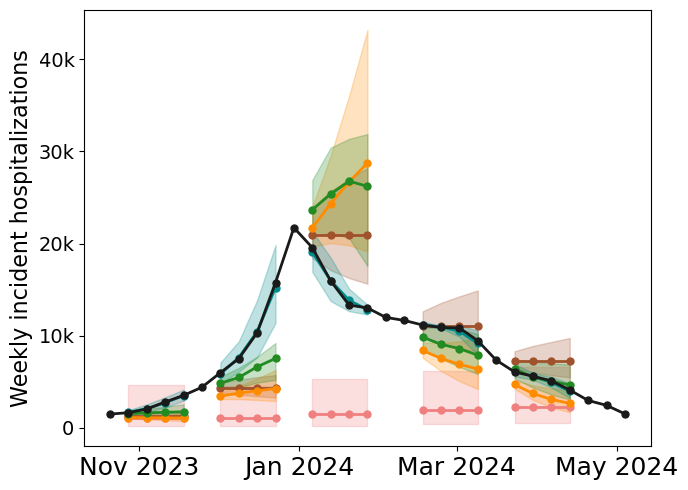

In [6]:
flu_hindcast = pd.read_parquet('benchmark forecasts/hindcasts/FluSight-hosp-hindcast-quantiles.parquet')
flu_hindcast['Model'] = 'hindcast'

flu_naive = pd.read_parquet('benchmark forecasts/naive/naive_flu_hosp_h12.parquet')
flu_naive['Model'] = 'naive'

flu_baseline = pd.read_parquet('benchmark forecasts/random walk baseline/flu_hosp_log_baseline_h12.pq')
flu_baseline['Model'] = 'baseline'

flu_ETS = pd.read_parquet('benchmark forecasts/trend baseline/flu_weeklyhosp_ets_models.parquet')
flu_ETS['Model'] = 'ETS'

fig,ax = plt.subplots(1,1,figsize=(7,5))

flu_naive['forecast_date'] = pd.to_datetime(flu_naive['forecast_date'])

location = 'US'
i=0
for date in ['2023-10-28', '2023-12-02', '2024-01-06', '2024-02-17', '2024-03-23',]:
    if pd.to_datetime(date) > pd.to_datetime('2023-09-01'):
        preds_baseline = flu_baseline[(flu_baseline.location==location)& (flu_baseline.horizon<=4) & \
                                  (flu_baseline.reference_date==pd.to_datetime(date)) &\
                                      (flu_baseline.target_end_date<=pd.to_datetime('2026-05-04'))]
    else:
        preds_baseline = flu_baseline[(flu_baseline.location==location)& (flu_baseline.horizon<=4) & \
                                  (flu_baseline.forecast_date==pd.to_datetime(date)) ]

    map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1

    quants = [(0.25,0.75)]

    for q in quants:
        interval_range = q[1] - q[0]
        alpha = map_alpha(interval_range)

        qupp = list(preds_baseline.groupby('horizon')['value'].quantile(q[0]))
        qlow = list(preds_baseline.groupby('horizon')['value'].quantile(q[1]))

        plt.fill_between(preds_baseline.target_end_date.unique(),qupp,qlow, color='sienna', alpha=alpha-.1)

    qmed = list(preds_baseline.groupby('horizon')['value'].quantile(.5))
    

    if i==0:
        plt.plot(preds_baseline.target_end_date.unique(),qmed,'-o', color='sienna', alpha=1,markersize=5,linewidth=2,
                                   label=r"Random Walk Baseline")
    else:
        plt.plot(preds_baseline.target_end_date.unique(),qmed,'-o', color='sienna', alpha=1,markersize=5,linewidth=2,)
        
    
    if pd.to_datetime(date) > pd.to_datetime('2023-09-01'):
        
        preds_naive = flu_naive[(flu_naive.location==location) & \
                                  (flu_naive.reference_date==pd.to_datetime(date) ) &\
                               (flu_naive.target_end_date<=pd.to_datetime('2026-05-04'))]
        
        preds_naive['horizon'] = ((preds_naive['target_end_date'] - preds_naive['reference_date']).dt.days)/7
        preds_naive = preds_naive[preds_naive.horizon<=3]

    else:
        preds_naive = flu_naive[(flu_naive.location==location) & \
                                  (flu_naive.forecast_date==pd.to_datetime(date) ) ]

    map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1

    quants = [(0.25,0.75)]

    for q in quants:
        interval_range = q[1] - q[0]
        alpha = map_alpha(interval_range)

        qupp = list(preds_naive.groupby('horizon')['value'].quantile(q[0]))
        qlow = list(preds_naive.groupby('horizon')['value'].quantile(q[1]))

        plt.fill_between(preds_naive.target_end_date.unique(),qupp,qlow, color='lightcoral', alpha=alpha-.1)

    qmed = list(preds_naive.groupby('horizon')['value'].quantile(.5))

    if i==0:
        plt.plot(preds_naive.target_end_date.unique(),qmed,'-o', color='lightcoral', alpha=1,markersize=5,linewidth=2,
                                   label=r"Naive Baseline")
    else:
        plt.plot(preds_naive.target_end_date.unique(),qmed,'-o', color='lightcoral', alpha=1,markersize=5,linewidth=2,)
     
    
    
    preds_ETS = flu_ETS[(flu_ETS.location==location)& (flu_ETS.horizon<=4) & \
                                  (flu_ETS.forecast_date==pd.to_datetime(date)-pd.Timedelta(days=3)) ]

    map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1

    quants = [(0.25,0.75)]

    for q in quants:
        interval_range = q[1] - q[0]
        alpha = map_alpha(interval_range)

        qupp = list(preds_ETS.groupby('horizon')['value'].quantile(q[0]))
        qlow = list(preds_ETS.groupby('horizon')['value'].quantile(q[1]))

        plt.fill_between(preds_ETS.target_end_date.unique(),qupp,qlow, color='darkorange', alpha=alpha-.1)

    qmed = list(preds_ETS.groupby('horizon')['value'].quantile(.5))
    

    if i==0:
        plt.plot(preds_ETS.target_end_date.unique(),qmed,'-o', color='darkorange', alpha=1,markersize=5,linewidth=2,
                                   label=r"Trend Baseline")
    else:
        plt.plot(preds_ETS.target_end_date.unique(),qmed,'-o', color='darkorange', alpha=1,markersize=5,linewidth=2,)
    
    end_date = Week.fromdate(pd.to_datetime(date))+3
    end_date = pd.to_datetime(end_date.enddate())
    
    preds_hind = flu_hindcast[(flu_hindcast.location==location) & \
                                  (flu_hindcast.target_end_date>=pd.to_datetime(date))&\
                                  (flu_hindcast.target_end_date<=end_date) &\
                             (flu_hindcast.target_end_date<=pd.to_datetime('2024-05-04'))]

    for q in quants:
        interval_range = q[1] - q[0]
        alpha = map_alpha(interval_range)

        qupp = list(preds_hind.groupby('target_end_date')['value'].quantile(q[0]))
        qlow = list(preds_hind.groupby('target_end_date')['value'].quantile(q[1]))

        plt.fill_between(preds_hind.target_end_date.unique(),qupp,qlow, color='darkcyan', alpha=alpha-.1)

    qmed = list(preds_hind.groupby('target_end_date')['value'].quantile(.5))

    if i==0:
        plt.plot(preds_hind.target_end_date.unique(),qmed,'-o', color='darkcyan', alpha=1,markersize=5,linewidth=2,
                                   label=fr"Hindcast")
    else:
        plt.plot(preds_hind.target_end_date.unique(),qmed,'-o', color='darkcyan', alpha=1,markersize=5,linewidth=2,)
        
    
    if pd.to_datetime(date) > pd.to_datetime('2023-09-01'):
        model = 'FluSight-ensemble'
        ensemble = pull_flusight_predictions(model,date)
        ensemble = ensemble[(ensemble.location==location) & (ensemble.horizon>=0) & (ensemble.target=='wk inc flu hosp')&\
                           (ensemble.target_end_date<=pd.to_datetime('2024-06-04'))]
    
    else:
        model = 'Flusight-ensemble'
        ensemble = pull_flusight_predictions_early(model,date)
        ensemble['horizon'] = ensemble['target'].apply(lambda x: int(x[0]))
        ensemble = ensemble[(ensemble.location==location) & (ensemble.horizon>=0) ]
        ensemble = ensemble.rename(columns={'quantile':'output_type_id', 'type':'output_type'})
                               
    ensemble['output_type_id'] = ensemble['output_type_id'].astype(float)
    
    for q in quants:
        interval_range = q[1] - q[0]
        alpha = map_alpha(interval_range)

        qupp = list(ensemble.groupby('horizon')['value'].quantile(q[0]))
        qlow = list(ensemble.groupby('horizon')['value'].quantile(q[1]))

        plt.fill_between(ensemble.target_end_date.unique(),qupp,qlow, color='forestgreen', alpha=alpha-.1)

    qmed = list(ensemble.groupby('horizon')['value'].quantile(.5))

    if i==0:
        plt.plot(ensemble.target_end_date.unique(),qmed,'-o', color='forestgreen', alpha=1,markersize=5,linewidth=2,
                                   label=r"Ensemble",)
    else:
        plt.plot(ensemble.target_end_date.unique(),qmed,'-o', color='forestgreen', alpha=1, markersize=5,linewidth=2,)
    
    i+=1
    
observations = pull_flu_surveillance_data()
observations = observations[observations['location'] == location]
observations['date'] = pd.to_datetime(observations['date'])

observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

observations=observations[(observations.date>=pd.to_datetime('2023-10-15')) & \
                          (observations.date<=pd.to_datetime('2024-05-05'))]

ax.plot(observations.date,observations.value, '-o', color='#1a1a1a', label = 'Surveillance data',
        markersize=5,linewidth=2,)
      
set_date_axis_fmt(ax)

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=18)

#set y axis 
ax.set_ylabel(f"Weekly incident hospitalizations",fontsize=16)
  
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else int(x)))
    
    
handles, labels = plt.gca().get_legend_handles_labels()
order = [4, 3,1,0,2,5]
#plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=13, loc='upper right')
    
#ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
 #loc='upper center',         # Align the center of the legend's top edge
  # bbox_to_anchor=(0.5, 1.15),  # Position it centered horizontally, just above the axes (y>1)
   # ncol=6,                     # Arrange items in 5 columns (making it horizontal)
    #fancybox=True,              # Optional: adds a nice background with rounded corners
    #shadow=True ,
     #    fontsize = 13)

plt.tight_layout()

plt.savefig('figs/fig1A-forecastviz.pdf')

plt.show()

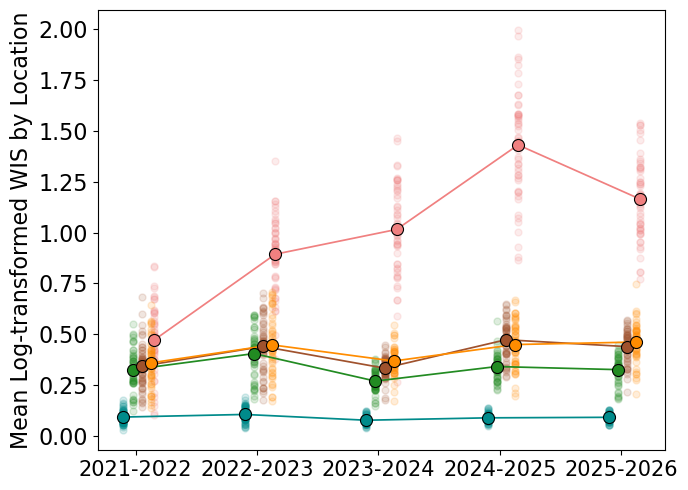

In [7]:
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble']))]
flu_ensemble = flu_ensemble[['team', 'location', 'reference_date', 'target_end_date', 'location_name',
                             'forecast_date', 'horizon', 'target', 'wis', 'log_wis', 'season']]
flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_ensemble.merge(flu_baseline)
flu_ensemble = flu_ensemble[flu_ensemble.horizon <= 3]

outcome = 'hosp'
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
df = flu_ensemble.copy()

flu_ensemble_h = df[['season', 'location', 'log_wis_hindcast']].copy()
flu_ensemble_h['model'] = 'Hindcast Model'
flu_ensemble_f = df[['season', 'location', 'log_wis']].copy()
flu_ensemble_f['model'] = 'FluSight Ensemble'
flu_baseline_b = flu_ensemble[['season', 'location', 'log_wis_lbaseline']].copy().dropna()
flu_baseline_b['model'] = 'Random Walk Baseline'
flu_ensemble_n = df[['season', 'location', 'log_wis_naive']].copy()
flu_ensemble_n['model'] = 'Naive Baseline'
flu_ensemble_ets = df[['season', 'location', 'log_wis_ets_baseline']].copy()
flu_ensemble_ets['model'] = 'Trend Baseline'

flu_ensemble_h = flu_ensemble_h.rename(columns={'log_wis_hindcast': 'log_wis'})
flu_ensemble_n = flu_ensemble_n.rename(columns={'log_wis_naive': 'log_wis'})
flu_baseline_b = flu_baseline_b.rename(columns={'log_wis_lbaseline': 'log_wis'})
flu_ensemble_ets = flu_ensemble_ets.rename(columns={'log_wis_ets_baseline': 'log_wis'})

all_data = pd.concat([flu_ensemble_h, flu_ensemble_f, flu_baseline_b, flu_ensemble_n, flu_ensemble_ets], ignore_index=True)

all_data = all_data[~all_data.location.isin(['78'])]

# Compute mean log_wis per season, location, model
loc_means = all_data.groupby(['season', 'location', 'model'])['log_wis'].mean().reset_index()

palette = {
    'Hindcast Model': 'darkcyan',
    'FluSight Ensemble': 'forestgreen',
    'Random Walk Baseline': 'sienna',
    'Naive Baseline': 'lightcoral',
    'Trend Baseline': 'darkorange'
}


seasons = loc_means['season'].unique()
models = ['Hindcast Model', 'FluSight Ensemble', 'Random Walk Baseline','Trend Baseline', 'Naive Baseline', ]
season_idx = {s: i for i, s in enumerate(sorted(seasons))}

offsets = {m: o for m, o in zip(models, [-0.1, -0.025, 0.05, 0.125, .15])}  # adjust these

for model, color in palette.items():
    subset = loc_means[loc_means['model'] == model]
    x_vals = [season_idx[s] + offsets[model] for s in subset['season']]
    
    ax.scatter(x_vals, subset['log_wis'], color=color, alpha=0.15, s=25, label=model)

    
overall_means = all_data.groupby(['season', 'model'])['log_wis'].mean().reset_index()

for model, color in palette.items():
    subset = overall_means[overall_means['model'] == model]
    xs = []
    ys = []
    for _, row in subset.iterrows():
        x_mean = season_idx[row['season']] + offsets[model]
        ax.scatter(x_mean, row['log_wis'], color=color, s=75, zorder=5, edgecolors='black', linewidths=0.8)
        
        xs.append(x_mean)
        ys.append(row['log_wis'])
        
    ax.plot(xs, ys, color=color, zorder=4,linewidth=1.25,)
    
    
ax.set_xticks(range(len(season_idx)))
ax.set_xticklabels(sorted(seasons), fontsize=16)


plt.xlabel('')
plt.ylabel('Mean Log-transformed WIS by Location', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('figs/fig1_fluhosp_scores.pdf')
plt.show()

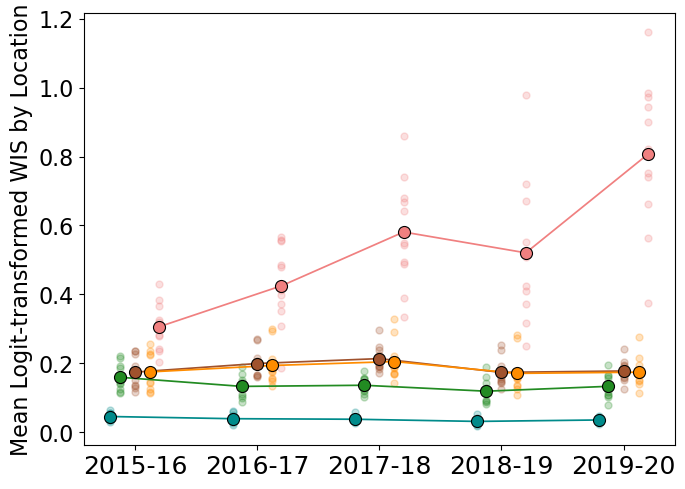

In [8]:
ILI_WIS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_WIS[ (ILI_WIS.horizon<=3) & (ILI_WIS.team=='UnwghtAvg') & (ILI_WIS.season!='2014-2015')]

fig,ax = plt.subplots(1,1,figsize=(7,5))

df = flu_ensemble.copy()

flu_ensemble_h = df[['season', 'logit_wis_hindcast','location']].copy()
flu_ensemble_h['model'] = 'Hindcast Model'
flu_ensemble_f = df[['season', 'logit_wis','location']].copy()
flu_ensemble_f['model'] = 'FluSight Ensemble'

flu_baseline_b = flu_ensemble[['season', 'logit_wis_logit_baseline','location']].copy().dropna()
flu_baseline_b['model'] = 'Random Walk Baseline'

flu_ensemble_n = df[['season', 'logit_wis_naive','location']].copy()
flu_ensemble_n['model'] = 'Naive Baseline'

flu_ensemble_ets = df[['season', 'logit_wis_ets_baseline','location']].copy()
flu_ensemble_ets['model'] = 'Trend Baseline'

# Rename columns to match
flu_ensemble_h = flu_ensemble_h.rename(columns={'logit_wis_hindcast': 'logit_wis'})
flu_ensemble_n = flu_ensemble_n.rename(columns={'logit_wis_naive': 'logit_wis'})
flu_baseline_b = flu_baseline_b.rename(columns={'logit_wis_logit_baseline': 'logit_wis'})
flu_ensemble_ets = flu_ensemble_ets.rename(columns={'logit_wis_ets_baseline': 'logit_wis'})


# Combine all data
all_data = pd.concat([flu_ensemble_h, flu_ensemble_f], ignore_index=True)
all_data = pd.concat([all_data, flu_baseline_b], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_n], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_ets], ignore_index=True)

# Compute mean log_wis per season, location, model
loc_means = all_data.groupby(['season', 'location', 'model'])['logit_wis'].mean().reset_index()
loc_means = loc_means.sort_values(by='season')

palette = {
    'Hindcast Model': 'darkcyan',
    'FluSight Ensemble': 'forestgreen',
    'Random Walk Baseline': 'sienna',
    'Naive Baseline': 'lightcoral',
    'Trend Baseline': 'darkorange'
}


seasons = loc_means['season'].unique()
models = ['Hindcast Model', 'FluSight Ensemble', 'Random Walk Baseline',  'Trend Baseline','Naive Baseline',]
season_idx = {s: i for i, s in enumerate(sorted(seasons))}

offsets = {m: o for m, o in zip(models, [-0.2, -0.125,0, 0.125, 0.2])}  # adjust these

for model, color in palette.items():
    subset = loc_means[loc_means['model'] == model]
    x_vals = [season_idx[s] + offsets[model] for s in subset['season']]
    
    ax.scatter(x_vals, subset['logit_wis'], color=color, alpha=0.25, s=25, label=model)

    
overall_means = all_data.groupby(['season', 'model'])['logit_wis'].mean().reset_index()

for model, color in palette.items():
    subset = overall_means[overall_means['model'] == model]
    xs = []
    ys = []
    for _, row in subset.iterrows():
        x_mean = season_idx[row['season']] + offsets[model]
        ax.scatter(x_mean, row['logit_wis'], color=color, s=75, zorder=5, edgecolors='black', linewidths=0.8)
        
        xs.append(x_mean)
        ys.append(row['logit_wis'])
        
    ax.plot(xs, ys, color=color, zorder=4,linewidth=1.25,)
    
    
ax.set_xticks(range(len(season_idx)))
ax.set_xticklabels(sorted([i[0:5]+i[-2:] for i in seasons]), fontsize=16)



plt.xlabel('')
plt.ylabel('Mean Logit-transformed WIS by Location', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

#plt.legend(fontsize=15, loc='upper left')
plt.tight_layout()

plt.savefig('figs/fig1_ILI_WIS_scores.pdf')

plt.show()

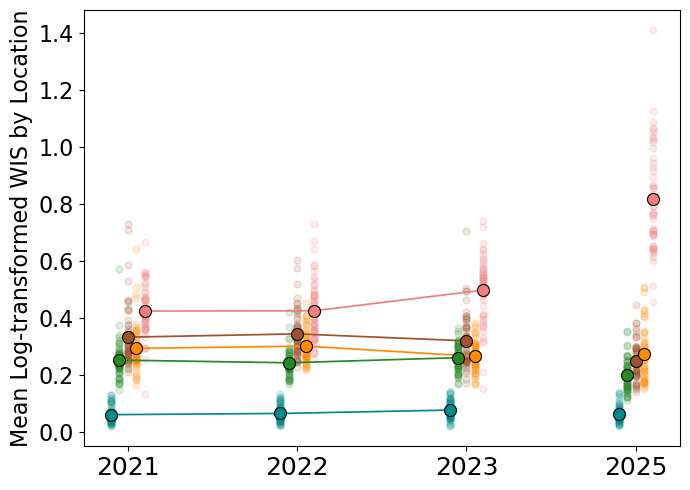

In [11]:
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_ensemble = covid_WIS[(covid_WIS.team.isin(['COVIDhub-4_week_ensemble', 'CovidHub-ensemble'])) ]

outcome = 'hosp' # repeat for 'case', 'death' and 'hosp' to get plots for COVID-19 cases and hospitalizations

covid_ensemble = covid_ensemble[(covid_ensemble.horizon<=3) & (covid_ensemble.outcome==outcome)]

fig,ax = plt.subplots(1,1,figsize=(7,5))

df = covid_ensemble.copy()

covid_ensemble_h = df[['season', 'log_wis_hindcast', 'location']].copy()
covid_ensemble_h['model'] = 'Hindcast Model'
covid_ensemble_f = df[['season', 'log_wis', 'location']].copy()
covid_ensemble_f['model'] = 'COVID Hub Ensemble'

covid_baseline_b = covid_ensemble[['season', 'log_wis_lbaseline', 'location']].copy().dropna()
covid_baseline_b['model'] = 'Random Walk Baseline'

covid_ensemble_n = df[['season', 'log_wis_naive', 'location']].copy()
covid_ensemble_n['model'] = 'Naive Baseline'

covid_ensemble_ets = df[['season', 'log_wis_ets_baseline', 'location']].copy()
covid_ensemble_ets['model'] = 'Trend Baseline'

# Rename columns to match
covid_ensemble_h = covid_ensemble_h.rename(columns={'log_wis_hindcast': 'log_wis'})
covid_ensemble_n = covid_ensemble_n.rename(columns={'log_wis_naive': 'log_wis'})
covid_baseline_b = covid_baseline_b.rename(columns={'log_wis_lbaseline': 'log_wis'})
covid_ensemble_ets = covid_ensemble_ets.rename(columns={'log_wis_ets_baseline': 'log_wis'})


# Combine all data
all_data = pd.concat([covid_ensemble_h, covid_ensemble_f], ignore_index=True)
all_data = pd.concat([all_data, covid_baseline_b], ignore_index=True)
all_data = pd.concat([all_data, covid_ensemble_n, covid_ensemble_ets], ignore_index=True)

all_data = all_data[~all_data.location.isin(['60'])]


# Compute mean log_wis per season, location, model
loc_means = all_data.groupby(['season', 'location', 'model'])['log_wis'].mean().reset_index()


palette = {
    'Hindcast Model': 'darkcyan',
    'COVID Hub Ensemble': 'forestgreen',
    'Random Walk Baseline': 'sienna',
    'Naive Baseline': 'lightcoral',
    'Trend Baseline': 'darkorange'
}


seasons = loc_means['season'].unique()
models = ['Hindcast Model', 'COVID Hub Ensemble', 'Random Walk Baseline','Trend Baseline', 'Naive Baseline']
season_idx = {s: i for i, s in enumerate(sorted(seasons))}

offsets = {m: o for m, o in zip(models, [-0.1, -0.05, 0, 0.05,0.1])}  # adjust these

for model, color in palette.items():
    subset = loc_means[loc_means['model'] == model]
    x_vals = [season_idx[s] + offsets[model] for s in subset['season']]
    
    ax.scatter(x_vals, subset['log_wis'], color=color, alpha=0.15, s=25, label=model)

    
overall_means = all_data.groupby(['season', 'model'])['log_wis'].mean().reset_index()

    
for model, color in palette.items():
    subset = overall_means[overall_means['model'] == model].copy()
    subset = subset.sort_values(by='season')

    xs = []
    ys = []
    for _, row in subset.iterrows():
        x_mean = season_idx[row['season']] + offsets[model]
        ax.scatter(x_mean, row['log_wis'], color=color, s=75, zorder=5, edgecolors='black', linewidths=0.8)

        if outcome == 'hosp' and row['season'] == '2025':
            # Draw what we have so far, then start a new segment
            ax.plot(xs, ys, color=color, zorder=4, linewidth=1.25)
            xs = []
            ys = []

        xs.append(x_mean)
        ys.append(row['log_wis'])

    # Draw the remaining segment
    ax.plot(xs, ys, color=color, zorder=4, linewidth=1.25)    
    
ax.set_xticks(range(len(season_idx)))
ax.set_xticklabels(sorted(seasons), fontsize=16)


plt.xlabel('')
plt.ylabel('Mean Log-transformed WIS by Location', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

#plt.legend(fontsize=15, loc='upper left')

plt.tight_layout()

plt.savefig(f'figs/fig1_covid_{outcome}_scores.pdf')

plt.show()

# Fig 2 - benchmark models at long horizons

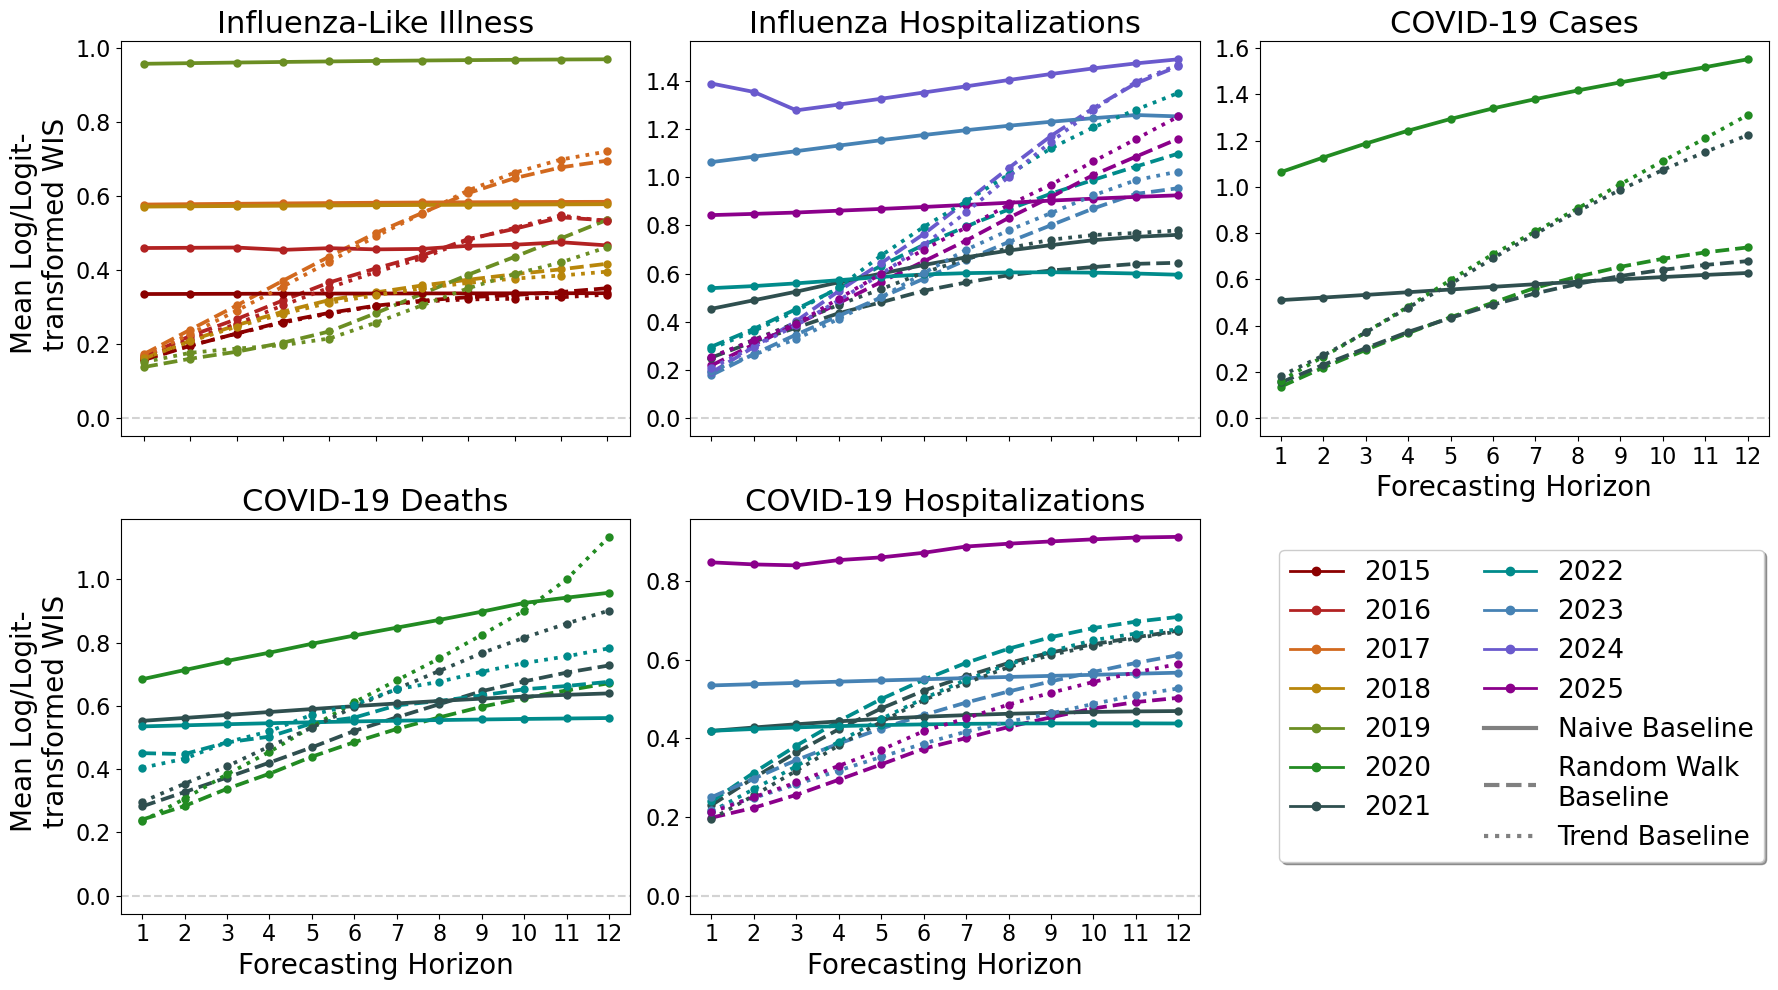

In [12]:
fig,ax = plt.subplots(2,3,figsize=(18,10), )

colors = ['#8B0000', '#B22222',  '#D2691E', '#B8860B',  '#6B8E23',  '#228B22',  '#2F4F4F',  '#008B8B', 
          '#4682B4',  '#6A5ACD',  '#8B008B', ]

alpha=1

ILI_WIS = pd.read_csv('scored forecasts/flusight_combined_WIS_h12.csv')
ILI_WIS['season'] = ILI_WIS['season'].apply(lambda x: str(x[0:4]))
ILI_WIS = ILI_WIS[ILI_WIS.season!='2014']

flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS_h12.parquet')
flu_baseline['season'] = flu_baseline['season'].apply(lambda x: str(x[0:4]))

covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS_h12.parquet')


all_seasons = set()
all_seasons.update(ILI_WIS['season'].unique())
all_seasons.update(flu_baseline['season'].unique())
all_seasons.update(covid_WIS['season'].unique())
all_seasons = sorted(list(all_seasons))

# Create a dictionary mapping each season to a color
season_color_map = {season: colors[i % len(colors)] for i, season in enumerate(all_seasons)}


plt.subplot(2,3,1)
# Flu ILI
ILI_WIS = pd.read_csv('scored forecasts/flusight_combined_WIS_h12.csv')
ILI_WIS['season'] = ILI_WIS['season'].apply(lambda x: str(x[0:4]))


ILI_WIS['horizon'] = ILI_WIS['horizon'].astype(int)

flu_ILI_filtered = ILI_WIS[(ILI_WIS['horizon'] >= 0) & (ILI_WIS.season!='2014')].copy()

flu_ILI_filtered['horizon'] = flu_ILI_filtered['horizon']+1
df = flu_ILI_filtered.groupby(['horizon','season'])[ 'logit_wis_logit_baseline', 'logit_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['logit_wis_logit_baseline'].mean().reset_index()

g = sns.pointplot(x='horizon', y='logit_wis_logit_baseline', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50), hue='season', legend=False,linestyle='--', markersize=4, palette=season_color_map,alpha=alpha)

df = flu_ILI_filtered.groupby(['horizon','season'])[ 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['logit_wis_naive'].mean().reset_index()

g = sns.pointplot(x='horizon', y='logit_wis_naive', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50),  hue='season',legend=False, markersize=4,linestyle='-', palette=season_color_map,alpha=alpha)


df = flu_ILI_filtered.groupby(['horizon','season'])[ 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['logit_wis_ets_baseline'].mean().reset_index()

g = sns.pointplot(x='horizon', y='logit_wis_ets_baseline', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50),  hue='season',legend=False, markersize=4,linestyle=':', palette=season_color_map,alpha=alpha)


plt.tick_params(labelbottom=False)
plt.yticks(fontsize=16)
plt.axhline(y=0, color='lightgray', linestyle='--')
plt.ylabel('Mean Log/Logit- \n transformed WIS', fontsize=20)
plt.title('Influenza-Like Illness', fontsize=22)
plt.xlabel('')

plt.subplot(2,3,2)
# Flu hosp
flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS_h12.parquet')
flu_baseline['season'] = flu_baseline['season'].apply(lambda x: str(x[0:4]))

flu_baseline['horizon'] = flu_baseline['horizon'].apply(lambda x: int(x/ np.timedelta64(1, 'D')))

flu_WIS_filtered = flu_baseline[(flu_baseline['horizon'] >= 0)&\
                              (~flu_baseline.location.isin(['60','78']))].copy()
flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['horizon','season'])['log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['log_wis_lbaseline'].mean().reset_index()

g = sns.pointplot(x='horizon', y='log_wis_lbaseline', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50), hue='season', legend=False, markersize=4,linestyle='--', palette=season_color_map,alpha=alpha)

# flu hosp naive
flu_WIS_filtered = flu_baseline[(flu_baseline['horizon'] >= 0)&\
                              (~flu_baseline.location.isin(['60','78']))].copy()
flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['horizon','season'])['log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['log_wis_naive'].mean().reset_index()

g = sns.pointplot(x='horizon', y='log_wis_naive', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50), hue='season', legend=False, linestyle='-', markersize=4, palette=season_color_map,alpha=alpha)


flu_WIS_filtered = flu_baseline[(flu_baseline['horizon'] >= 0)&\
                              (~flu_baseline.location.isin(['60','78']))].copy()

flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['horizon','season'])['log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
vals = df.groupby(['horizon','season'])['log_wis_ets_baseline'].mean().reset_index()

g = sns.pointplot(x='horizon', y='log_wis_ets_baseline', data=vals, label='FluSight Hospitalizations',
                  errorbar=("pi", 50), hue='season', legend=False, linestyle=':', markersize=4, palette=season_color_map,alpha=alpha)


plt.tick_params(labelbottom=False)
plt.yticks(fontsize=16)
plt.axhline(y=0, color='lightgray', linestyle='--')
plt.xlabel('', fontsize=18)
plt.ylabel('', fontsize=18)
plt.title('Influenza Hospitalizations', fontsize=22)


# COVID
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS_h12.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(str)
covid_WIS['horizon'] = covid_WIS['horizon'].apply(lambda x: math.ceil(x))
covid_WIS['horizon'] = covid_WIS.horizon.astype(int)

z=3
for target in covid_WIS.outcome.unique():
    plt.subplot(2,3,z)
    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) &  (~covid_WIS.location.isin(['60']))].copy()
    
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon'].astype(int)
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1

    if target=='hosp':
        label = 'Hospitalizations'
    elif target=='death':
        label='Deaths'
    elif target=='case':
        label='Cases'

    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]
    df = df.groupby(['horizon','season'])['log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    vals = df.groupby(['horizon','season'])['log_wis_lbaseline'].mean().reset_index()
    g = sns.pointplot(x='horizon', y='log_wis_lbaseline', data=vals, label=f'COVID {label}',
                      hue='season', legend=False, markersize=4, linestyle='--', palette=season_color_map,alpha=alpha)

    # naive
    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0)  &  (~covid_WIS.location.isin(['60']))].copy()
    
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon'].astype(int)
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1
    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]
    df = df.groupby(['horizon','season'])['log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    vals = df.groupby(['horizon','season'])['log_wis_naive'].mean().reset_index()
    g = sns.pointplot(x='horizon', y='log_wis_naive', data=vals, label=f'COVID {label}',
                      hue='season', legend=False, linestyle='-', markersize=4, palette=season_color_map,alpha=alpha)
    
    
    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0)  &  (~covid_WIS.location.isin(['60']))].copy()
    
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon'].astype(int)
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1
    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]
    df = df.groupby(['horizon','season'])['log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    vals = df.groupby(['horizon','season'])['log_wis_ets_baseline'].mean().reset_index()
    g = sns.pointplot(x='horizon', y='log_wis_ets_baseline', data=vals, label=f'COVID {label}',
                      hue='season', legend=False, linestyle=':', markersize=4, palette=season_color_map,alpha=alpha)
    
   
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.axhline(y=0, color='lightgray', linestyle='--')
    plt.xlabel('Forecasting Horizon', fontsize=20)
    plt.title(f'COVID-19 {label}', fontsize=22)
    
    if z==4:
        plt.ylabel('Mean Log/Logit- \n transformed WIS', fontsize=20)
    else:
        plt.ylabel('', fontsize=18)
    
    z+=1

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.axhline(y=0, color='lightgray', linestyle='--')
ax[0,2].set_xlabel('Forecasting Horizon', fontsize=18)

# Create custom legend
from matplotlib.lines import Line2D


season_handles = [
    Line2D([0], [0], color=season_color_map[season], marker='o', 
           linestyle='-', linewidth=2, markersize=6, label=f'{season}')
    for season in sorted(season_color_map.keys())
]

style_handles = [
    Line2D([0], [0], color='gray', linestyle='-', linewidth=3, label='Naive Baseline'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=3, label='Random Walk \nBaseline'),
    Line2D([0], [0], color='gray', linestyle=':', linewidth=3, label='Trend Baseline')
]

# Combine legends
all_handles = season_handles + style_handles    
    
fig.legend(handles=all_handles, loc='lower right', bbox_to_anchor=(.99, .12), 
          ncol=2, fontsize=19, fancybox=True, shadow=True  )
    

plt.tight_layout()

ax[0,2].set_xlabel('Forecasting Horizon', fontsize=20)
ax[0,2].tick_params(labelbottom=True)  

fig.delaxes(ax[1,2])


plt.savefig('figs/fig2-benchmarks_long_horizon.pdf')
plt.show()

# Fig 3 - skill scores by season, horizon, and disease outcome

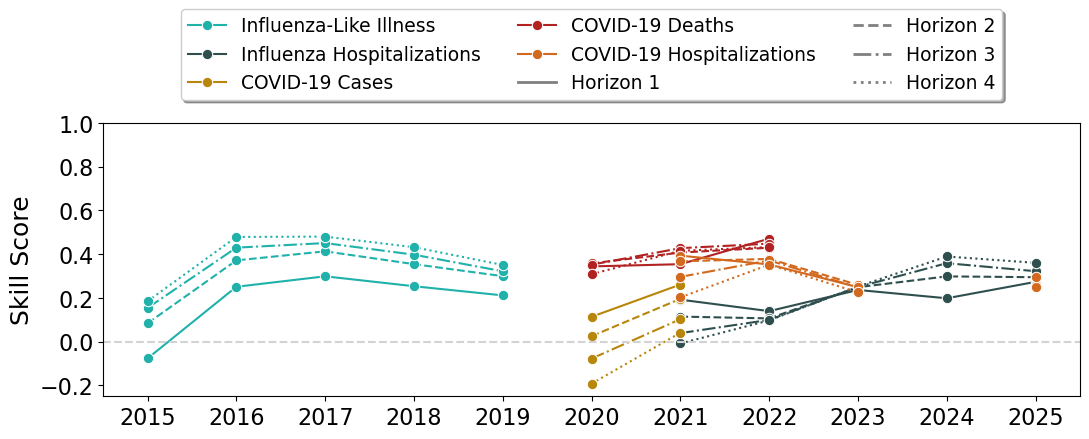

In [13]:

fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()


df = df.groupby(['team','season','horizon'])['logit_wis', 'logit_wis_logit_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_logit_baseline'])

vals = df.groupby(['season'])['ss'].mean()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
        label=f'Influenza-Like Illness')

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_ensemble = flu_ensemble[['team', 'location', 'reference_date','target_end_date','location_name',
                             'forecast_date','horizon',  'target','wis','log_wis','season']]

flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')


flu_ensemble = flu_ensemble.merge(flu_baseline)
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    
    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
       
    df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
    
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
      
    i+=1

    
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]

        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])

       
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
                label=f'{label}')  
    
        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,4,8,12,16] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  linewidth=2, label='Horizon 1'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Horizon 2'),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=2, label='Horizon 3'),
    Line2D([0], [0], color='gray', linestyle=':',  linewidth=2, label='Horizon 4')
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]


ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center', bbox_to_anchor=(0.5, 1.45), ncol=3, fancybox=True,shadow=True)


plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])


plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/fig3-skillscore_RW.pdf')
plt.show()

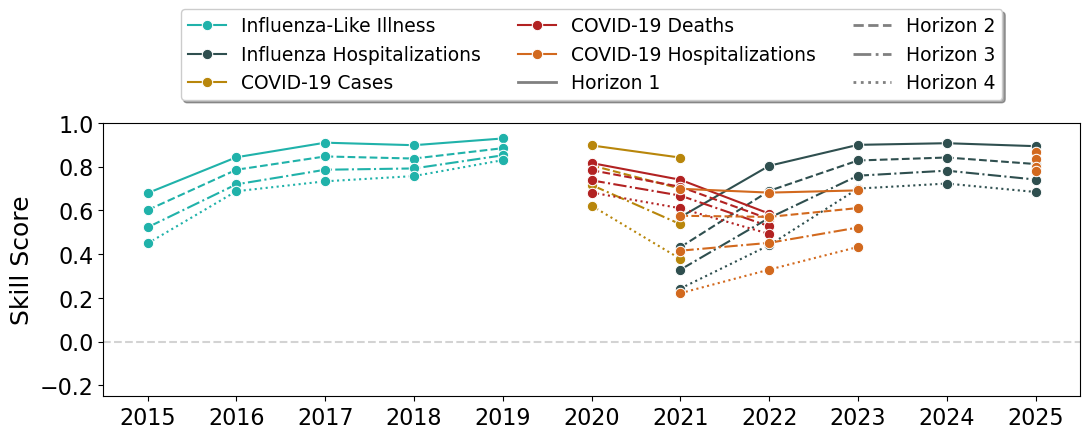

In [14]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()

df = df.groupby(['team','season','horizon'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])

vals = df.groupby(['season'])['ss'].mean()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
        label=f'Influenza-Like Illness')

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_ensemble = flu_ensemble[['team', 'location', 'reference_date','target_end_date','location_name',
                             'forecast_date','horizon',  'target','wis','log_wis','season']]

flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')


flu_ensemble = flu_ensemble.merge(flu_baseline)
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    
    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
     
    df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
    
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
    
    i+=1
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]

        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])

        
        if target=='hosp':
            #df = df[df.season>2020]
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
                label=f'{label}')
    
        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,4,8,12,16] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  linewidth=2, label='Horizon 1'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Horizon 2'),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=2, label='Horizon 3'),
    Line2D([0], [0], color='gray', linestyle=':',  linewidth=2, label='Horizon 4')
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center',         
    bbox_to_anchor=(0.5, 1.45),  
    ncol=3,                      
    fancybox=True,              
 shadow=True                  
)

plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/fig3-skillscore_naive.pdf')
plt.show()

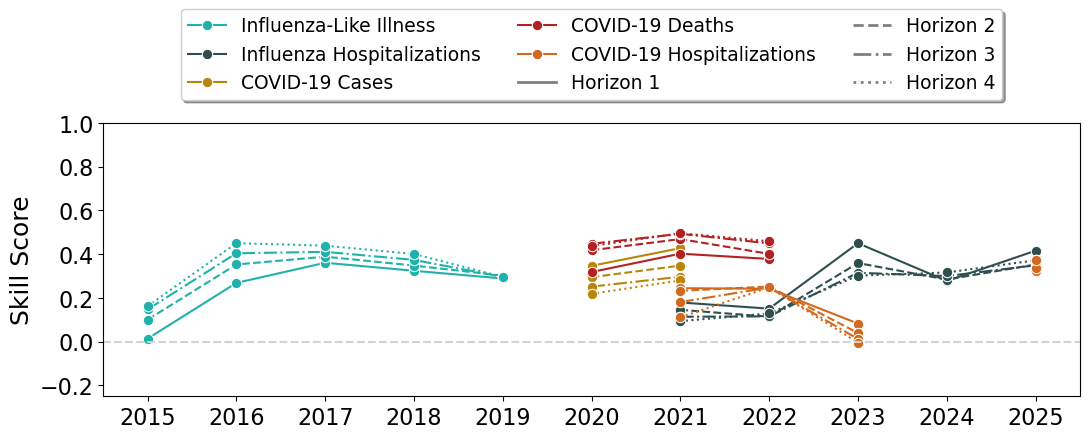

In [16]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()


df = df.groupby(['team','season','horizon'])['logit_wis', 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])

vals = df.groupby(['season'])['ss'].mean()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
        label=f'Influenza-Like Illness')


flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_ensemble = flu_ensemble[['team', 'location', 'reference_date','target_end_date','location_name',
                             'forecast_date','horizon',  'target','wis','log_wis','season']]

flu_baseline = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')


flu_ensemble = flu_ensemble.merge(flu_baseline)
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    
    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    
    df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
    
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
   
    i+=1

    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]
        
        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])

       
        if target=='hosp':
            #df = df[df.season>2020]
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
                label=f'{label}')
    
        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,4,8,12,16] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  linewidth=2, label='Horizon 1'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Horizon 2'),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=2, label='Horizon 3'),
    Line2D([0], [0], color='gray', linestyle=':',  linewidth=2, label='Horizon 4')
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center',          
    bbox_to_anchor=(0.5, 1.45),  
    ncol=3,                     
    fancybox=True,              
 shadow=True                
)


plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])



plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/fig3-skillscore_trend.pdf')
plt.show()

# Fig 4 - forecast improvement 

In [17]:
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_ensemble = flu_ensemble[['team', 'location', 'reference_date','target_end_date','location_name',
                             'forecast_date','horizon',  'target','wis','log_wis','season']]

flu_ensemble = flu_ensemble.merge(flu_baseline)
flu_WIS = flu_ensemble[(flu_ensemble.horizon<=3) ]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))

flu_WIS['location_name'] = flu_WIS['location_name'].apply(lambda x: 'United States' if x=='US' else x)
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:

    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'].isin([0,3])) &  
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78'])) ].copy()

    flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

    dffilt = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]

    df = dffilt.groupby(['team','location_name','horizon', 'season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
    df = df.groupby(['location_name','horizon', 'season'])[['ss']].mean().reset_index()
    
    dfoverall = dffilt.groupby(['team','horizon', 'season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    dfoverall['ss'] = (dfoverall['log_wis'] - dfoverall['log_wis_naive']) / (dfoverall['log_wis_hindcast'] - dfoverall['log_wis_naive'])
    dfoverall = dfoverall.groupby(['horizon', 'season'])[['ss']].mean().reset_index()
    
    i+=1

dfnaive_fluhosp=df.copy()
dfnaive_fluhosp_overall=dfoverall.copy()

In [18]:
ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))

flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['horizon'] = flu_WIS['horizon']+2

i=0
for team in ['UnwghtAvg', ]:

    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'].isin([1,4])) &  # Horizon filter
    (flu_WIS['team'].isin(['UnwghtAvg'])) ].copy()

    dffilt = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]

    df = dffilt.groupby(['team','location','horizon', 'season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])
    df = df.groupby(['location','horizon', 'season'])[['ss']].mean().reset_index()
    
    dfoverall = dffilt.groupby(['team','horizon', 'season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()
    dfoverall['ss'] = (dfoverall['logit_wis'] - dfoverall['logit_wis_naive']) / (dfoverall['logit_wis_hindcast'] - dfoverall['logit_wis_naive'])
    dfoverall = dfoverall.groupby(['horizon', 'season'])[['ss']].mean().reset_index()
    
    i+=1

dfnaive_ILI=df.copy()
dfnaive_ILI_overall=dfoverall.copy()

In [19]:
dfnaive = {}
dfnaive_overall = {}

#target='hosp' # repeat for target = 'case' and 'death' to get results for all outcomes

for target in ['case', 'death', 'hosp']:
    covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
    covid_WIS['season'] = covid_WIS['season'].astype(int)

    teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']

    covid_WIS = covid_WIS[covid_WIS.team.isin(teams)]
    covid_WIS['team'] = covid_WIS['team'].apply(lambda x: 'COVIDhub-4_week_ensemble' if x=='CovidHub-ensemble' else x)

    i=0
    for team in ['COVIDhub-4_week_ensemble']:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'].isin([0,3])) &  # Horizon filter
       (~covid_WIS.location.isin(['60'])) ].copy()

        covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1


        if target=='case':
            covid_WIS_filtered = covid_WIS_filtered[covid_WIS_filtered.season!=2022]

        elif target=='hosp':
            covid_WIS_filtered = covid_WIS_filtered[covid_WIS_filtered.season!=2025]


        dffilt = covid_WIS_filtered[(covid_WIS_filtered.team==team)  & (covid_WIS_filtered.outcome==target)]

        df = dffilt.groupby(['team','location_name','horizon', 'season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
        df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
        df = df.groupby(['location_name','horizon', 'season'])[['ss']].mean().reset_index()

        dfoverall = dffilt.groupby(['team','horizon', 'season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
        dfoverall['ss'] = (dfoverall['log_wis'] - dfoverall['log_wis_naive']) / (dfoverall['log_wis_hindcast'] - dfoverall['log_wis_naive'])
        dfoverall = dfoverall.groupby(['horizon', 'season'])[['ss']].mean().reset_index()

        i+=1

    dfnaive[target]=df.copy()
    dfnaive_overall[target]=dfoverall.copy()

In [20]:
dfnaive_case = dfnaive['case']
dfnaive_case_overall = dfnaive_overall['case']

dfnaive_death = dfnaive['death']
dfnaive_death_overall = dfnaive_overall['death']

dfnaive_hosp = dfnaive['hosp']
dfnaive_hosp_overall = dfnaive_overall['hosp']

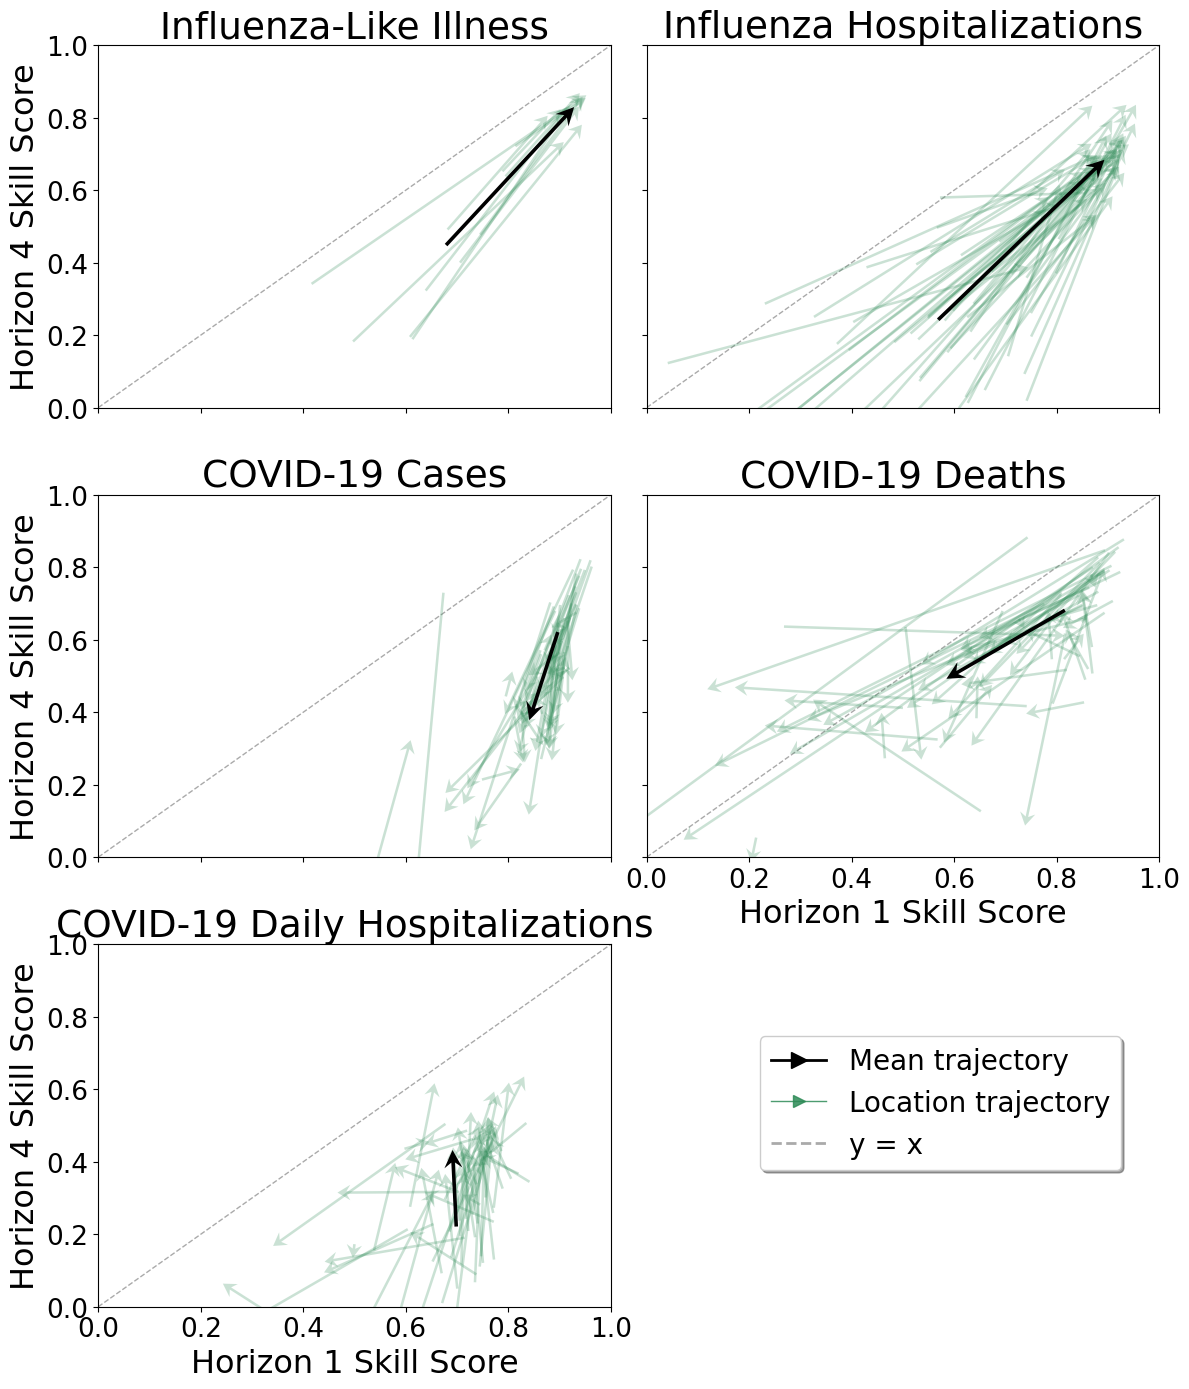

In [21]:
fig, ax = plt.subplots(3,2,figsize=(12, 14), sharex=True, sharey=True)
ax = ax.flatten()
labels = ['Influenza-Like Illness', 'Influenza Hospitalizations', 'COVID-19 Cases', 'COVID-19 Deaths',
         'COVID-19 Daily Hospitalizations']

i=0

dfoveralls = [dfnaive_ILI_overall, dfnaive_fluhosp_overall, dfnaive_case_overall, dfnaive_death_overall, 
              dfnaive_hosp_overall]

x=0
y=0
for df in [dfnaive_ILI, dfnaive_fluhosp, dfnaive_case, dfnaive_death, dfnaive_hosp]:
    
    dfoverall = dfoveralls[i].copy()
    
    if labels[i] == 'Influenza-Like Illness':
        df_pivot = (
            df[df["horizon"].isin([1, 4])]
            .pivot_table(index=["location", 'season'], columns="horizon", values="ss")
            .reset_index() .rename(columns={1: "horizon_1", 4: "horizon_4"}) )
        
        firsts = df_pivot.groupby("location").first().reset_index()
        lasts  = df_pivot.groupby("location").last().reset_index()
        
        
        df_pivot_overall = (
            dfoverall[dfoverall["horizon"].isin([1, 4])]
            .pivot_table(index=[ 'season'], columns="horizon", values="ss")
            .reset_index().rename(columns={1: "horizon_1", 4: "horizon_4"}) )
        
        firsts_overall = df_pivot_overall[df_pivot_overall.season==df_pivot_overall.season.min()]
        lasts_overall  = df_pivot_overall[df_pivot_overall.season==df_pivot_overall.season.max()]
    else:
        df_pivot = (
            df[df["horizon"].isin([1,4])]
            .pivot_table(index=["location_name", 'season'], columns="horizon", values="ss")
            .reset_index() .rename(columns={1: "horizon_1", 4: "horizon_4"}) )
        
        df_pivot_overall = (
            dfoverall[dfoverall["horizon"].isin([1,4])]
            .pivot_table(index=['season'], columns="horizon", values="ss")
            .reset_index() .rename(columns={1: "horizon_1", 4: "horizon_4"}) )

        if labels[i] == 'COVID-19 Hospitalizations':
            df_pivot = df_pivot[(df_pivot.season!=2025) ]
            df_pivot_overall = df_pivot_overall[(df_pivot_overall.season!=2025) ]

        firsts = df_pivot.groupby("location_name").first().reset_index()
        lasts  = df_pivot.groupby("location_name").last().reset_index()
        
        firsts_overall = df_pivot_overall[df_pivot_overall.season==df_pivot_overall.season.min()]
        lasts_overall  = df_pivot_overall[df_pivot_overall.season==df_pivot_overall.season.max()]

    mx = firsts["horizon_1"].values
    my = firsts["horizon_4"].values
    dx = lasts["horizon_1"].values - firsts["horizon_1"].values
    dy = lasts["horizon_4"].values - firsts["horizon_4"].values
    
    mx_overall = firsts_overall["horizon_1"].values
    my_overall = firsts_overall["horizon_4"].values
    dx_overall = lasts_overall["horizon_1"].values - firsts_overall["horizon_1"].values
    dy_overall = lasts_overall["horizon_4"].values - firsts_overall["horizon_4"].values


    plt.subplot(3,2,i+1)
    magnitude = np.sqrt(dx**2 + dy**2)

    q = ax[i].quiver(mx, my, dx, dy, scale=1, scale_units="xy", angles="xy", width=0.005,
        headwidth=6, headlength=5, headaxislength=3.5, color="seagreen", alpha=0.25,)

    mean_q = ax[i].quiver(mx_overall, my_overall, dx_overall, dy_overall, scale=1, scale_units="xy", angles="xy",
        width=0.007, headwidth=5, headlength=5, headaxislength=3.5, color="black", zorder=5,)


    from matplotlib.lines import Line2D
    
    ax[i].set_xlim([0,1])
    ax[i].set_ylim([0,1])

    lims = [min(ax[i].get_xlim()[0], ax[i].get_ylim()[0]),
            max(ax[i].get_xlim()[1], ax[i].get_ylim()[1])]
    ax[i].plot(lims, lims, linestyle="--", linewidth=1, color="#aaa", zorder=0)

    legend_elements = [
        # Mean trajectory arrow
        Line2D([0], [0], marker=">", color="black", label="Mean trajectory",
               markersize=12, linewidth=2),
        # Small arrows = individual locations
        Line2D([0], [0], marker=">", color="seagreen", label="Location trajectory",
               markersize=8, linewidth=1, alpha=0.85),
        # y=x dashed line
        Line2D([0], [0], linestyle="--", color="#aaa", linewidth=2, label="y = x"),]

    if i not in [0,1,2]:
        ax[i].set_xlabel("Horizon 1 Skill Score", fontsize=23)
    
    if i in [0,2,4]:
        ax[i].set_ylabel("Horizon 4 Skill Score", fontsize=23)
    
    plt.xticks(fontsize=19)
    plt.yticks(fontsize=19)
    
    plt.title(labels[i], fontsize=27)
    
    i+=1
    

fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(.95, .15), 
          ncol=1, fontsize=20, fancybox=True, shadow=True  )
    
ax[3].tick_params(labelbottom=True, labelsize=19) 

fig.delaxes(ax[5])

plt.tight_layout()
plt.savefig('figs/fig4-skill_trajectory_naive.pdf')
plt.show()